# Quantum annealing for uplink NOMA detection

**EE599 · Mohamed S. Abuain · University of Tripoli**

This notebook checks the QUBO formulation against exact ML, compares ML and SIC under four modulation schemes, and optionally submits a frame to D-Wave Leap. The seeded classical sweep is a new reproducible demonstration; the thesis documents the historical QPU study.

![Uplink NOMA model](../assets/uplink-noma-model.png)


## 1. Channel and receiver

The base station observes $y=\sum_k H_ks_k+n$. The coefficients include transmit power, Rayleigh fading, and distance-dependent path loss. The exhaustive ML detector searches all joint symbol vectors. SIC detects the strongest received channel first and cancels each hard decision.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
root = Path.cwd()
if not (root / "src").exists(): root = root.parent
sys.path.insert(0, str(root / "src"))
from noma_detection import (Scenario, candidate_bits, compare_detectors, decode_ml,
    decode_sic, draw_frame, qubo_energy, qubo_from_frame, sample_qpu, symbols_from_bits)
SEED = 2024
POWERS_DBM = (-20, -10, 0, 10, 20, 30)
FRAMES_PER_POWER = 1000
SCENARIOS = (
    Scenario("BPSK", (100, 150, 200, 250, 300, 350, 400, 450, 500, 550), noise_dbm=-60),
    Scenario("QPSK", (100, 200, 300, 400, 500), noise_dbm=-60),
    Scenario("16QAM", (100, 300, 500), noise_dbm=-60),
    Scenario("64QAM", (100, 500), noise_dbm=-60),
)
[(s.modulation, s.users) for s in SCENARIOS]


## 2. Verify the QUBO

With $s_k=c+\sum_b w_bq_{kb}$, expansion of $|y-\sum_k H_ks_k|^2$ gives the QUBO and a constant offset. The following checks **every** candidate for a two-user QPSK frame and checks the minimizer.


In [2]:
rng = np.random.default_rng(SEED)
example = Scenario("QPSK", (100, 250), noise_dbm=-60)
y, H, sent = draw_frame(example, tx_dbm=10, rng=rng)
candidates = candidate_bits(example.users, example.modulation)
symbols = symbols_from_bits(candidates, example.modulation)
Q, offset = qubo_from_frame(y, H, example.modulation)
direct = np.abs(symbols @ H - y) ** 2
expanded = np.array([qubo_energy(bits, Q, offset) for bits in candidates])
assert np.allclose(direct, expanded, rtol=1e-9, atol=1e-24)
ml_bits = decode_ml(y, H, candidates, symbols)
assert np.array_equal(ml_bits, candidates[np.argmin(expanded)])
print(f"QUBO variables: {len(sent)}; maximum objective difference: {np.max(np.abs(direct-expanded)):.3e}")
print("Transmitted:", sent.tolist(), "ML/QUBO:", ml_bits.tolist(), "SIC:", decode_sic(y,H,example.modulation).tolist())


QUBO variables: 4; maximum objective difference: 1.059e-22
Transmitted: [0, 1, 0, 1] ML/QUBO: [0, 1, 0, 1] SIC: [0, 1, 0, 1]


## 3. BER on shared random frames

Each modulation and power uses 1,000 independent frames. ML and SIC evaluate identical transmitted bits, fading, and noise. BER divides bit errors by all transmitted bits. Noise is −60 dBm of total complex noise power; path-loss exponent is 2.7. QAM uses peak normalization and binary amplitude bit labels, rather than Gray coding. These settings define a separate experiment from the thesis plots.


In [3]:
results = [compare_detectors(s, POWERS_DBM, frames=FRAMES_PER_POWER, seed=SEED+i)
           for i, s in enumerate(SCENARIOS)]
for scenario, result in zip(SCENARIOS, results):
    print(f"{scenario.modulation:5s} {scenario.users:2d} users | 30 dBm: ML {result['ml'][-1]:.4f}, SIC {result['sic'][-1]:.4f}")


BPSK  10 users | 30 dBm: ML 0.0569, SIC 0.2936
QPSK   5 users | 30 dBm: ML 0.0694, SIC 0.2361
16QAM  3 users | 30 dBm: ML 0.2065, SIC 0.2597
64QAM  2 users | 30 dBm: ML 0.1924, SIC 0.1899


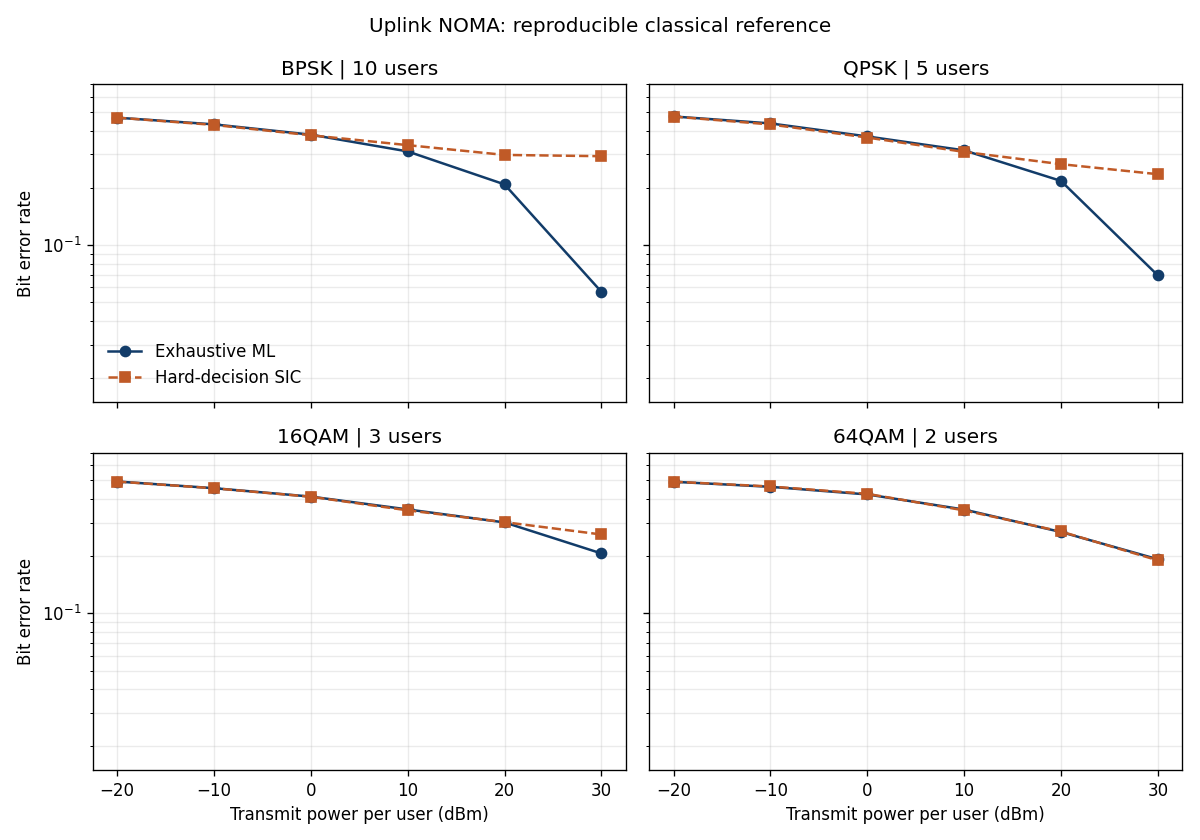

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, scenario, result in zip(axes.flat, SCENARIOS, results):
    ax.plot(POWERS_DBM, result["ml"], "o-", color="#123c69", label="Exhaustive ML")
    ax.plot(POWERS_DBM, result["sic"], "s--", color="#c05a27", label="Hard-decision SIC")
    ax.set(title=f"{scenario.modulation} | {scenario.users} users", yscale="log", ylim=(0.015, 0.7))
    ax.grid(alpha=0.25, which="both")
for ax in axes[1]: ax.set_xlabel("Transmit power per user (dBm)")
for ax in axes[:, 0]: ax.set_ylabel("Bit error rate")
axes[0, 0].legend(frameon=False)
fig.suptitle("Uplink NOMA: reproducible classical reference")
fig.tight_layout()
plt.show()


## Original thesis figures

The historical work compared QPU detection with classical methods as the user count changed, and reported timing. The [thesis](../docs/EE599-thesis.pdf) supplies the original parameters and analysis.

![Thesis BER versus number of users](../assets/thesis-ber-vs-users.png)

![Thesis timing](../assets/thesis-timing.png)


## 4. Optional D-Wave Leap run

Install `pip install -e '.[qpu]'`, configure credentials with `dwave setup`, and set `RUN_QPU = True`. This runs one BPSK frame through the QPU and compares its best returned sample with exact ML for that frame. It requires Leap access and consumes account quota; one frame does not establish BER.


In [5]:
RUN_QPU = False
if RUN_QPU:
    scenario = Scenario("BPSK", (100, 200, 300, 400), noise_dbm=-60)
    y, H, sent = draw_frame(scenario, 20, np.random.default_rng(SEED))
    bits = candidate_bits(scenario.users, scenario.modulation)
    exact = decode_ml(y, H, bits, symbols_from_bits(bits, scenario.modulation))
    qpu_bits, info = sample_qpu(y, H, scenario.modulation, num_reads=100)
    print("Transmitted:", sent.tolist(), "Exact ML:", exact.tolist(), "QPU:", qpu_bits.tolist())
    print("Agreement:", np.array_equal(qpu_bits, exact), "Solver:", info["solver"])
    print("Objective:", info["energy_with_offset"], "Timing:", info["timing"])


## References

- Mohamed S. Abuain, *Quantum Annealing-Driven Maximum Likelihood Detection for NOMA in Next-Generation Wireless Networks*, EE599 thesis, University of Tripoli, 2024. [Thesis](../docs/EE599-thesis.pdf)
- Mohamed Abuain and Osama Abusaid, [project research paper](../docs/quantum-annealing-noma-paper.pdf).
- [D-Wave coordinated multipoint example](https://github.com/dwave-examples/coordinated-multipoint-notebook), a quantum optimization workflow reference.
